# Hands-on Lesson: Molecular Dynamics of a 3D Lennard-Jones Fluid

This notebook is designed for a computational chemistry course and can be incorporated into a Jupyter Book.  
It introduces a **simple molecular dynamics (MD) engine** for a 3D Lennard-Jones (LJ) fluid and then uses **MDAnalysis** to compute two standard observables:

1. The **radial distribution function**, $g(r)$
2. The **mean-squared displacement**, $\mathrm{MSD}(t)$

From the long-time behavior of the MSD, we estimate the **self-diffusion constant**,
\begin{equation}
D = \frac{1}{6}\frac{d}{dt}\langle |\mathbf r(t)-\mathbf r(0)|^2\rangle.
\end{equation}

---

## Learning goals

By the end of this lesson, you should be able to:

- simulate a simple LJ fluid in three dimensions with periodic boundary conditions,
- control the reduced **density** and **temperature**,
- understand how LJ reduced units simplify the simulation,
- compute and interpret $g(r)$,
- compute the MSD and extract a diffusion constant.

---

## Notes

- The MD code below is intentionally simple and optimized for **clarity**, not speed.
- All simulations are done in **Lennard-Jones reduced units**:
  - $m = 1$
  - $\sigma = 1$
  - $\varepsilon = 1$
  - $k_B = 1$
- In these units:
  - reduced temperature is $T^* = k_B T / \varepsilon$,
  - reduced density is $\rho^* = N\sigma^3/V$,
  - reduced time is $t^* = t\sqrt{\varepsilon/(m\sigma^2)}$.

You can also vary $\varepsilon$ and $\sigma$ explicitly, but for teaching purposes it is often easiest to think in reduced units.

## Theory background

### The Lennard-Jones pair potential

For a pair of particles separated by distance $r$,
\begin{equation}
U_\mathrm{LJ}(r) = 4\varepsilon\left[\left(\frac{\sigma}{r}\right)^{12} - \left(\frac{\sigma}{r}\right)^6\right].
\end{equation}

- The $r^{-12}$ term models short-range repulsion.
- The $r^{-6}$ term models dispersion attraction.

In this notebook we use a **cutoff** $r_c$ to truncate the potential. We also use a **shifted potential** so that $U(r_c)=0$.

### Periodic boundary conditions

To mimic a bulk fluid, particles move inside a cubic box of side length $L$, and interactions are computed using the **minimum image convention**.

### Radial distribution function

The radial distribution function $g(r)$ describes how particle density varies with distance from a reference particle. For an ideal gas, $g(r) \approx 1$ at all $r$ (away from finite-size effects). For a liquid, $g(r)$ shows structure such as coordination shells.

### Mean-squared displacement

The MSD is defined as
\begin{equation}
\mathrm{MSD}(t) = \left\langle |\mathbf r_i(t) - \mathbf r_i(0)|^2 \right\rangle.
\end{equation}

At long times in 3D diffusion,
\begin{equation}
\mathrm{MSD}(t) \approx 6Dt.
\end{equation}
So the diffusion constant is obtained from the slope of the linear regime.

## Run a simulation

A good starting point for a simple LJ liquid is:

- `n_cells = 4`  → 256 atoms
- `rho = 0.80`
- `temperature = 1.00`
- `dt = 0.005`
- No thermostat for an NVE simulation

These values usually produce a liquid-like state in reduced LJ units.

Try changing:
- `rho` to make the fluid more dilute or more crowded,
- `temperature` to make the fluid more ordered or more mobile,
- `epsilon` to effectively strengthen or weaken the interaction scale.

In [1]:
import numpy as np
from lj_fluid_md_class import LennardJonesMD
# I am going to comment out the simulation run for posting purposes
#sim = LennardJonesMD(
#    n_cells=4,
#    rho=0.8,
#    temperature=1.0,
#    n_steps=5000,
#    dt=0.005,
#    thermostat_interval=None,   # for NVE
#)

#results = sim.run()
# save the object
#import pickle
#
#with open("sim.pkl", "wb") as f:
#    pickle.dump(sim, f)
## Writte the trajectory in pdb and xyz formats
#sim.write_pdb("lj_fluid.pdb")
#sim.write_trajectory("lj_fluid.xyz")     

In [2]:
# load the simulation object
import pickle
with open("sim.pkl", "rb") as f:
    sim = pickle.load(f)

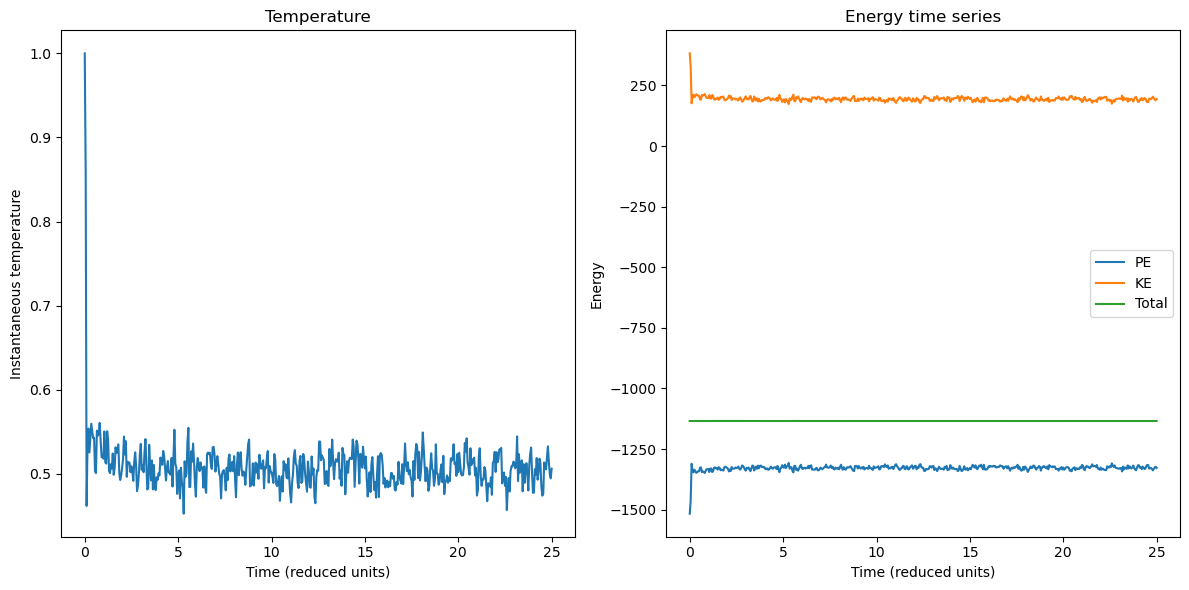

In [3]:
import matplotlib.pyplot as plt
import numpy as np
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].plot(sim.times, sim.temperatures)
axes[0].set_xlabel("Time (reduced units)")
axes[0].set_ylabel("Instantaneous temperature")
axes[0].set_title("Temperature")

axes[1].plot(sim.times, sim.potential_energies, label="PE")
axes[1].plot(sim.times, sim.kinetic_energies, label="KE")
axes[1].plot(sim.times, sim.total_energies, label="Total")
axes[1].set_xlabel("Time (reduced units)")
axes[1].set_ylabel("Energy")
axes[1].set_title("Energy time series")
axes[1].legend()

plt.tight_layout()
plt.show()

## Optional: view the LJ fluid inside the notebook

Yes — if `nglview` is installed, you can view the trajectory directly in the notebook.  
A convenient workflow is:

1. write the PDB and wrapped DCD files,
2. load them with **MDAnalysis**,
3. pass the `Universe` to `nglview`.

This is not required for the analysis, but it is very helpful for helping students connect the trajectory file to the particle motion.


In [4]:
#Run this cell if you have MDAnalysis and nglview are installed.

import MDAnalysis as md
import nglview as nv
#
u_view = md.Universe("lj_fluid.pdb", "lj_fluid.xyz")
view = nv.show_mdanalysis(u_view)
view.clear_representations()
view.add_spacefill(radius=0.5)
view.center()
view

NGLWidget(max_frame=500)

## Compute the radial distribution function

For a one-component fluid, the idea is:

- loop over saved frames,
- compute all unique pair distances using the minimum-image convention,
- bin those distances into a histogram,
- normalize by the ideal-gas number of neighbors expected in each spherical shell.

For shell $[r, r + \Delta r]$, the shell volume is
\begin{equation}
\Delta V = \frac{4\pi}{3}\left[(r+\Delta r)^3 - r^3\right].
\end{equation}
If the number density is $\rho = N/V$, then the ideal-gas expectation for the number of neighbors around one particle in that shell is
\begin{equation}
\rho\, \Delta V.
\end{equation}

Because we count each pair only once, the proper normalization for the histogram of unique pairs is
\begin{equation}
\frac{N\, n_\mathrm{frames}\, \rho\, \Delta V}{2}.
\end{equation}

In [5]:
def radial_distribution_function(traj, box_length, r_max=None, n_bins=100):
    """
    Compute g(r) from a wrapped trajectory of a one-component fluid.

    Parameters
    ----------
    traj : (n_frames, N, 3) ndarray
        Wrapped coordinates.
    box_length : float
        Cubic box length.
    r_max : float or None
        Maximum distance for the RDF. If None, use box_length / 2.
    n_bins : int
        Number of histogram bins.

    Returns
    -------
    r_centers : (n_bins,) ndarray
        Bin centers.
    g_r : (n_bins,) ndarray
        Radial distribution function.
    counts : (n_bins,) ndarray
        Raw pair counts accumulated over all frames.
    """
    traj = np.asarray(traj)
    n_frames, n_atoms, _ = traj.shape
    volume = box_length**3
    number_density = n_atoms / volume

    if r_max is None:
        r_max = box_length / 2.0

    edges = np.linspace(0.0, r_max, n_bins + 1)
    counts = np.zeros(n_bins, dtype=float)

    for frame in traj:
        for i in range(n_atoms - 1):
            rij = frame[i + 1:] - frame[i]
            rij = minimum_image(rij, box_length)
            distances = np.linalg.norm(rij, axis=1)
            hist, _ = np.histogram(distances, bins=edges)
            counts += hist

    shell_volumes = (4.0 / 3.0) * np.pi * (edges[1:]**3 - edges[:-1]**3)
    normalization = 0.5 * n_frames * n_atoms * number_density * shell_volumes

    g_r = counts / normalization
    r_centers = 0.5 * (edges[:-1] + edges[1:])

    return r_centers, g_r, counts

In [6]:

r_custom, g_custom, counts_custom = radial_distribution_function(
    results["wrapped_traj"],
    box_length=results["box_length"],
    r_max=results["box_length"] / 2.0,
    n_bins=100,
)

plt.figure(figsize=(6, 4))
plt.plot(r_custom, g_custom)
plt.xlabel("r")
plt.ylabel("g(r)")
plt.title("Radial distribution function")
plt.tight_layout()
plt.show()


NameError: name 'results' is not defined

Can also use MDAnalysis `InterRDF` to compute this

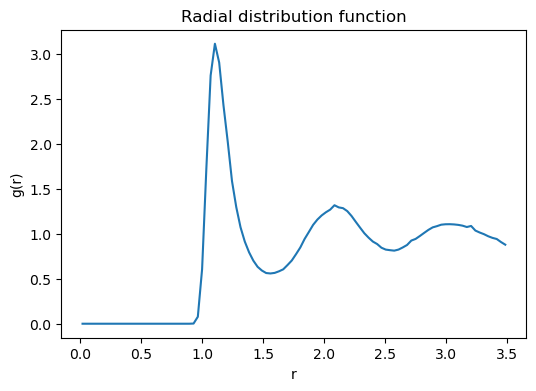

In [49]:
import MDAnalysis as mda
from MDAnalysis.analysis.rdf import InterRDF
import matplotlib.pyplot as plt
from MDAnalysis.transformations.boxdimensions import set_dimensions

u = mda.Universe("lj_fluid.pdb", "lj_fluid.xyz")
# Need to add box information to trajectory
u.trajectory.add_transformations(
    set_dimensions(np.array([sim.box_length, sim.box_length, sim.box_length, 90.0, 90.0, 90.0], dtype=np.float32))
)
# all particles
atoms = u.atoms

rdf = InterRDF(
    atoms,
    atoms,
    nbins=100,
    range=(0.0, 3.5),  
    norm="rdf",
    exclusion_block=(1, 1),   
)

rdf.run()

r = rdf.results.bins
g_r = rdf.results.rdf

plt.plot(r, g_r)
plt.xlabel("r")
plt.ylabel("g(r)")
plt.title("Radial distribution function")
plt.show()

### Interpreting $g(r)$

- **Small \(r\)**: $g(r) \approx 0$ because the repulsive core excludes close contacts.
- **First peak**: most probable nearest-neighbor distance.
- **Oscillations**: liquid-like short-range order.
- **Long range**: $g(r) \to 1$ for a homogeneous fluid.

## Compute the MSD

For the MSD, the unwrapped trajectory is important because particles may cross the periodic boundaries many times during the simulation.

In [36]:
import numpy as np

def compute_msd(unwrapped_traj, max_lag=None):
    """
    Compute the mean-squared displacement MSD(t) from an unwrapped trajectory.

    Parameters
    ----------
    unwrapped_traj : ndarray, shape (n_frames, n_particles, 3)
        Particle positions as a function of time, using unwrapped coordinates.
    max_lag : int or None, optional
        Maximum time lag (in frames) to include. If None, uses n_frames - 1.

    Returns
    -------
    lags : ndarray, shape (n_lags,)
        Lag times in units of frames.
    msd : ndarray, shape (n_lags,)
        Mean-squared displacement for each lag.
    """
    unwrapped_traj = np.asarray(unwrapped_traj)
    n_frames, n_particles, dim = unwrapped_traj.shape

    if dim != 3:
        raise ValueError("Trajectory must have shape (n_frames, n_particles, 3).")

    if max_lag is None:
        max_lag = n_frames - 1
    max_lag = min(max_lag, n_frames - 1)

    lags = np.arange(1, max_lag + 1)
    msd = np.zeros(max_lag, dtype=float)

    for lag in lags:
        disp = unwrapped_traj[lag:] - unwrapped_traj[:-lag]
        sq_disp = np.sum(disp**2, axis=2)   # shape: (n_origins, n_particles)
        msd[lag - 1] = np.mean(sq_disp)

    return lags, msd



def estimate_diffusion_constant(times, msd, fit_start_fraction=0.5, fit_end_fraction=1.0):
    """
    Fit the linear regime of the MSD and return the slope and diffusion constant.

    Parameters
    ----------
    times : ndarray
        Time points.
    msd : ndarray
        Mean-squared displacement values.
    fit_start_fraction, fit_end_fraction : float
        Fractions of the trajectory used for the fit.

    Returns
    -------
    slope : float
    diffusion_constant : float
    intercept : float
    mask : ndarray of bool
        Mask indicating the fit region.
    """
    n = len(times)
    i0 = int(fit_start_fraction * n)
    i1 = int(fit_end_fraction * n)

    x = times[i0:i1]
    y = msd[i0:i1]

    slope, intercept = np.polyfit(x, y, 1)
    diffusion_constant = slope / 6.0

    mask = np.zeros(n, dtype=bool)
    mask[i0:i1] = True

    return slope, diffusion_constant, intercept, mask

In [31]:
lags, msd = compute_msd(results["unwrapped_traj"])

time = lags * sim.dt * sim.sample_every

Estimated D = 0.02295031842610205


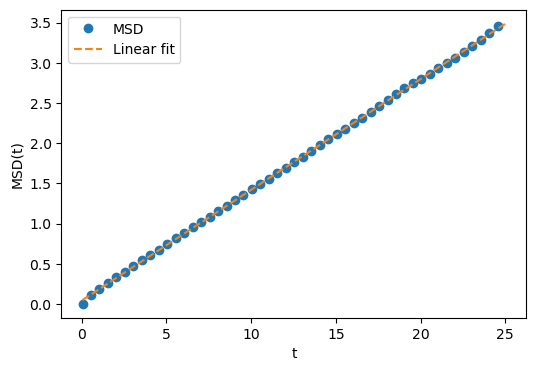

In [43]:
slope, D, intercept, _ = estimate_diffusion_constant(time, msd, fit_start_fraction=0.2, fit_end_fraction=1.0)

print("Estimated D =", D)

plt.plot(time[::10], msd[::10], 'o', label="MSD")
plt.plot(time, slope*time + intercept, "--", label="Linear fit")
plt.xlabel("t")
plt.ylabel("MSD(t)")
plt.legend()
plt.show()

Can also be done using MDAnlsysis `EinsteinMSD` 

In [ ]:

# Uncomment and run this cell to use MDAnalysis MSD/D calculation

# import MDAnalysis as md
# from MDAnalysis.analysis.msd import EinsteinMSD

# u_msd = md.Universe("lj_topology.pdb", "lj_unwrapped.dcd")

# msd_analysis = EinsteinMSD(u_msd, select="all", msd_type="xyz", fft=False)
# msd_analysis.run()

# msd = msd_analysis.results.timeseries
# times = results["times"]

# slope, D, intercept, fit_mask = estimate_diffusion_constant(
#     times, msd, fit_start_fraction=0.5, fit_end_fraction=1.0
# )

# plt.figure(figsize=(6, 4))
# plt.plot(times, msd, label="MSD(t)")
# plt.plot(times[fit_mask], slope * times[fit_mask] + intercept, "--", label=f"Linear fit, D = {D:.4f}")
# plt.xlabel("Time (reduced units)")
# plt.ylabel("MSD")
# plt.title("Mean-squared displacement")
# plt.legend()
# plt.tight_layout()
# plt.show()

# print(f"Estimated diffusion constant D = {D:.6f} (reduced units)")

## Hands-on Assignment

1. **Knowledge check**
    - Why does the temperature drop for the simluation run in the published version of this notebook?

2. **Density dependence**
   - Run simultions at `rho = 0.4`, `0.8`, and `1.0`.
   - Compute and plot (all on same plot) all three $g(r)$s
   - How do the peak heights and positions change?

3. **Temperature dependence**
   - Compare MSD curves at `temperature = 0.7`, `1.0`, and `1.5`.
   - How does the diffusion constant change?

4. **Thermostat choice**
   - Run with `thermostat_interval=100` and compare with NVE simulation.
   - Does the energy remain approximately constant?

---